#  Optimisation des Prix 

## Objectif
On va calculer le prix optimal pour chaque catégorie et estimer le gain potentiel de chiffre d'affaires.

## Méthode
Pour chaque catégorie :
1. On part du prix actuel et des ventes actuelles
2. On utilise l'élasticité calculée dans le notebook 03
3. On cherche le prix qui maximise le CA avec scipy.optimize
4. On compare CA actuel vs CA optimisé

## Contrainte
On limite l'augmentation de prix à **+20% maximum** pour rester réaliste et éviter de choquer les clients.

In [1]:
# ============================================================
# IMPORTS ET CHARGEMENT DES DONNÉES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize_scalar

# Données nettoyées
df = pd.read_csv('../data/df_clean.csv')

# Résultats des élasticités
elasticites = pd.read_csv('../data/elasticites.csv')

print(" Données chargées")
print(f"   - df        : {df.shape[0]:,} lignes")
print(f"   - elasticites : {elasticites.shape[0]} catégories")
print(f"\n=== Aperçu des élasticités ===")
print(elasticites.head())

 Données chargées
   - df        : 108,660 lignes
   - elasticites : 53 catégories

=== Aperçu des élasticités ===
                categorie  elasticite     r2  nb_ventes  prix_moyen  \
0             Ordinateurs       0.018  0.000        199     1098.92   
1         Téléphonie Fixe       0.001  0.000        255      216.92   
2          Électroménager      -0.003  0.000        754      104.55   
3  Instruments de Musique      -0.004  0.001        651      283.13   
4     Ustensiles Ménagers      -0.004  0.034       6795       90.60   

     opportunite  
0  🟢 Opportunité  
1  🟢 Opportunité  
2  🟢 Opportunité  
3  🟢 Opportunité  
4  🟢 Opportunité  


## 2. Calcul du CA actuel par catégorie

Avant d'optimiser, on calcule le chiffre d'affaires actuel  
de chaque catégorie. C'est notre point de référence.

CA actuel = prix moyen × nombre de ventes

In [4]:
# ============================================================
# CALCUL DU CA ACTUEL PAR CATÉGORIE
# ============================================================

# Calculer le CA actuel pour chaque catégorie
ca_actuel = (df.groupby('categorie')
               .agg(
                   prix_moyen=('prix', 'mean'),
                   nb_ventes=('commande_id', 'count'),
                   ca_actuel=('prix', 'sum')
               )
               .round(2)
               .reset_index())

# Fusionner avec les élasticités
# On garde uniquement les colonnes utiles depuis elasticites
df_optim = elasticites[['categorie', 'elasticite', 'opportunite']].merge(
    ca_actuel, 
    on='categorie', 
    how='inner'
)

print(f" Colonnes disponibles : {df_optim.columns.tolist()}")
print(f" CA actuel calculé pour {len(df_optim)} catégories")
print(f"\n=== Top 10 catégories par CA actuel ===")
print(df_optim.nlargest(10, 'ca_actuel')[['categorie', 'prix_moyen', 'nb_ventes', 'ca_actuel']].to_string(index=False))
print(f"\n CA total actuel : {df_optim['ca_actuel'].sum():,.0f} R$")

 Colonnes disponibles : ['categorie', 'elasticite', 'opportunite', 'prix_moyen', 'nb_ventes', 'ca_actuel']
 CA actuel calculé pour 53 catégories

=== Top 10 catégories par CA actuel ===
              categorie  prix_moyen  nb_ventes  ca_actuel
         Beauté & Santé      130.28       9465 1233131.72
      Montres & Cadeaux      199.04       5859 1166176.98
Literie & Salle de bain       93.44      10953 1023434.76
        Sport & Loisirs      113.25       8431  954852.55
           Informatique      116.26       7644  888724.61
   Meubles & Décoration       87.25       8160  711927.69
    Ustensiles Ménagers       90.60       6795  615628.69
                Gadgets      164.12       3718  610204.10
             Automobile      139.85       4140  578966.65
                 Jouets      116.94       4030  471286.48

 CA total actuel : 12,947,451 R$


CA total actuel : 12 947 451 R$

Les 3 plus grosses catégories sont :

- Beauté & Santé : 1 233 131 R$ soit 9 465 ventes
- Montres & Cadeaux : 1 166 176 R$ soit 5 859 ventes
- Literie & Salle de bain : 1 023 434 R$ soit 10 953 ventes

## 3. Calcul du prix optimal par catégorie

Pour chaque catégorie, on cherche le prix qui maximise le CA.  
On va utiliser scipy.optimize qui teste automatiquement des milliers de prix dans une fourchette donnée.

### Formule du CA estimé
CA(prix) = prix × ventes_actuelles × (1 + élasticité × (prix - prix_actuel) / prix_actuel)

In [ ]:
# ============================================================
# FONCTION D'OPTIMISATION DU PRIX
# ============================================================

def optimiser_prix(prix_actuel, nb_ventes, elasticite, max_hausse=0.20):
    """
    Trouve le prix qui maximise le CA pour une catégorie.
    
    Paramètres :
    - prix_actuel : prix moyen actuel de la catégorie
    - nb_ventes   : nombre de ventes actuelles
    - elasticite  : élasticité prix de la catégorie
    - max_hausse  : hausse maximale autorisée (défaut : 20%)
    
    Retourne :
    - prix_optimal : float
    - ca_optimal   : float
    """
    
    def ca_negatif(prix):
        # Variation de prix en %
        variation = (prix - prix_actuel) / prix_actuel
        # Estimation des nouvelles ventes
        nouvelles_ventes = nb_ventes * (1 + elasticite * variation)
        # CA estimé (négatif car minimize cherche le minimum)
        return -(prix * nouvelles_ventes)
    
    # On cherche le meilleur prix entre prix actuel et prix actuel + 20%
    resultat = minimize_scalar(
        ca_negatif,
        bounds=(prix_actuel, prix_actuel * (1 + max_hausse)),
        method='bounded'
    )
    
    prix_optimal = resultat.x
    ca_optimal = -resultat.fun  # On repasse en positif
    
    return round(prix_optimal, 2), round(ca_optimal, 2)

# Test sur Beauté & Santé
ligne = df_optim[df_optim['categorie'] == 'Beauté & Santé'].iloc[0]
prix_opt, ca_opt = optimiser_prix(ligne['prix_moyen'], ligne['nb_ventes'], ligne['elasticite'])

print(f"=== Test sur 'Beauté & Santé' ===")
print(f"Prix actuel  : {ligne['prix_moyen']:.2f} R$")
print(f"Prix optimal : {prix_opt:.2f} R$")
print(f"CA actuel    : {ligne['ca_actuel']:,.0f} R$")
print(f"CA optimal   : {ca_opt:,.0f} R$")
print(f"Gain estimé  : {ca_opt - ligne['ca_actuel']:,.0f} R$ (+{(ca_opt/ligne['ca_actuel']-1)*100:.1f}%)")

In [5]:
# ============================================================
# FONCTION D'OPTIMISATION DU PRIX
# ============================================================

def optimiser_prix(prix_actuel, nb_ventes, elasticite, max_hausse=0.20):
    """
    Trouve le prix qui maximise le CA pour une catégorie.
    
    Paramètres :
    - prix_actuel : prix moyen actuel de la catégorie
    - nb_ventes   : nombre de ventes actuelles
    - elasticite  : élasticité prix de la catégorie
    - max_hausse  : hausse maximale autorisée (défaut : 20%)
    
    Retourne :
    - prix_optimal : float
    - ca_optimal   : float
    """
    
    def ca_negatif(prix):
        # Variation de prix en %
        variation = (prix - prix_actuel) / prix_actuel
        # Estimation des nouvelles ventes
        nouvelles_ventes = nb_ventes * (1 + elasticite * variation)
        # CA estimé (négatif car minimize cherche le minimum)
        return -(prix * nouvelles_ventes)
    
    # On cherche le meilleur prix entre prix actuel et prix actuel + 20%
    resultat = minimize_scalar(
        ca_negatif,
        bounds=(prix_actuel, prix_actuel * (1 + max_hausse)),
        method='bounded'
    )
    
    prix_optimal = resultat.x
    ca_optimal = -resultat.fun  # On repasse en positif
    
    return round(prix_optimal, 2), round(ca_optimal, 2)

# Test sur Beauté & Santé
ligne = df_optim[df_optim['categorie'] == 'Beauté & Santé'].iloc[0]
prix_opt, ca_opt = optimiser_prix(ligne['prix_moyen'], ligne['nb_ventes'], ligne['elasticite'])

print(f"=== Test sur 'Beauté & Santé' ===")
print(f"Prix actuel  : {ligne['prix_moyen']:.2f} R$")
print(f"Prix optimal : {prix_opt:.2f} R$")
print(f"CA actuel    : {ligne['ca_actuel']:,.0f} R$")
print(f"CA optimal   : {ca_opt:,.0f} R$")
print(f"Gain estimé  : {ca_opt - ligne['ca_actuel']:,.0f} R$ (+{(ca_opt/ligne['ca_actuel']-1)*100:.1f}%)")

=== Test sur 'Beauté & Santé' ===
Prix actuel  : 130.28 R$
Prix optimal : 156.34 R$
CA actuel    : 1,233,132 R$
CA optimal   : 1,476,465 R$
Gain estimé  : 243,333 R$ (+19.7%)


## 4. Optimisation pour toutes les catégories

On applique la fonction sur toutes les catégories vertes et oranges. On exclut les catégories rouges (risque) car une hausse de prix pourrait faire baisser le CA.

In [6]:
# ============================================================
# OPTIMISATION POUR TOUTES LES CATÉGORIES
# ============================================================

resultats_optim = []

for _, ligne in df_optim.iterrows():
    
    # On skip les catégories à risque
    if ligne['opportunite'] == '🔴 Risque':
        resultats_optim.append({
            'categorie'     : ligne['categorie'],
            'opportunite'   : ligne['opportunite'],
            'prix_actuel'   : ligne['prix_moyen'],
            'prix_optimal'  : ligne['prix_moyen'],  # Pas de changement
            'ca_actuel'     : ligne['ca_actuel'],
            'ca_optimal'    : ligne['ca_actuel'],   # Pas de changement
            'gain_rs'       : 0,
            'gain_pct'      : 0
        })
        continue
    
    # Calcul du prix optimal
    prix_opt, ca_opt = optimiser_prix(
        ligne['prix_moyen'], 
        ligne['nb_ventes'], 
        ligne['elasticite']
    )
    
    gain_rs  = ca_opt - ligne['ca_actuel']
    gain_pct = (ca_opt / ligne['ca_actuel'] - 1) * 100
    
    resultats_optim.append({
        'categorie'    : ligne['categorie'],
        'opportunite'  : ligne['opportunite'],
        'prix_actuel'  : ligne['prix_moyen'],
        'prix_optimal' : prix_opt,
        'ca_actuel'    : ligne['ca_actuel'],
        'ca_optimal'   : ca_opt,
        'gain_rs'      : round(gain_rs, 2),
        'gain_pct'     : round(gain_pct, 2)
    })

# Convertir en DataFrame
optim_df = pd.DataFrame(resultats_optim)
optim_df = optim_df.sort_values('gain_rs', ascending=False).reset_index(drop=True)

# Résumé global
ca_total_actuel  = optim_df['ca_actuel'].sum()
ca_total_optimal = optim_df['ca_optimal'].sum()
gain_total       = ca_total_optimal - ca_total_actuel
gain_total_pct   = (ca_total_optimal / ca_total_actuel - 1) * 100

print("=" * 55)
print("         RÉSULTATS DE L'OPTIMISATION")
print("=" * 55)
print(f"""
 CA total actuel  : {ca_total_actuel:>15,.0f} R$
 CA total optimal : {ca_total_optimal:>15,.0f} R$
 Gain total       : {gain_total:>15,.0f} R$
 Gain en %        : {gain_total_pct:>14.1f}%
""")
print("=" * 55)

print(f"\n=== Top 10 catégories par gain ===")
print(optim_df.head(10)[['categorie', 'prix_actuel', 'prix_optimal', 'gain_rs', 'gain_pct']].to_string(index=False))

         RÉSULTATS DE L'OPTIMISATION

 CA total actuel  :      12,947,451 R$
 CA total optimal :      15,371,613 R$
 Gain total       :       2,424,162 R$
 Gain en %        :           18.7%


=== Top 10 catégories par gain ===
              categorie  prix_actuel  prix_optimal   gain_rs  gain_pct
         Beauté & Santé       130.28        156.34 243333.06     19.73
      Montres & Cadeaux       199.04        238.85 230154.67     19.74
Literie & Salle de bain        93.44        112.13 199790.62     19.52
        Sport & Loisirs       113.25        135.90 187941.28     19.68
           Informatique       116.26        139.51 174505.78     19.64
   Meubles & Décoration        87.25        104.70 140373.79     19.72
    Ustensiles Ménagers        90.60        108.72 122532.64     19.90
                Gadgets       164.12        196.94 117493.78     19.25
             Automobile       139.85        167.82 114279.61     19.74
                 Jouets       116.94        140.33  92086.35  

On obtient un accroissement de +18.7% de CA soit +2 424 162 R$. Ce qui dépasse l'objectif initial de +15%.

On observe que toutes les catégories du top 10 ont un gain autour de +19-20% vu qu'on a fixé une limite de +20% de hausse. Les catégories avec le plus gros gain sont celles qui ont le plus de ventes :

- Beauté & Santé : +243 333 R$ (9 465 ventes)
- Montres & Cadeaux : +230 154 R$ (5 859 ventes)
- Literie & Salle de bain : +199 790 R$ (10 953 ventes)

## 5. Visualisation des résultats

On visualise les gains par catégorie pour identifier rapidement où se concentre le potentiel d'optimisation.

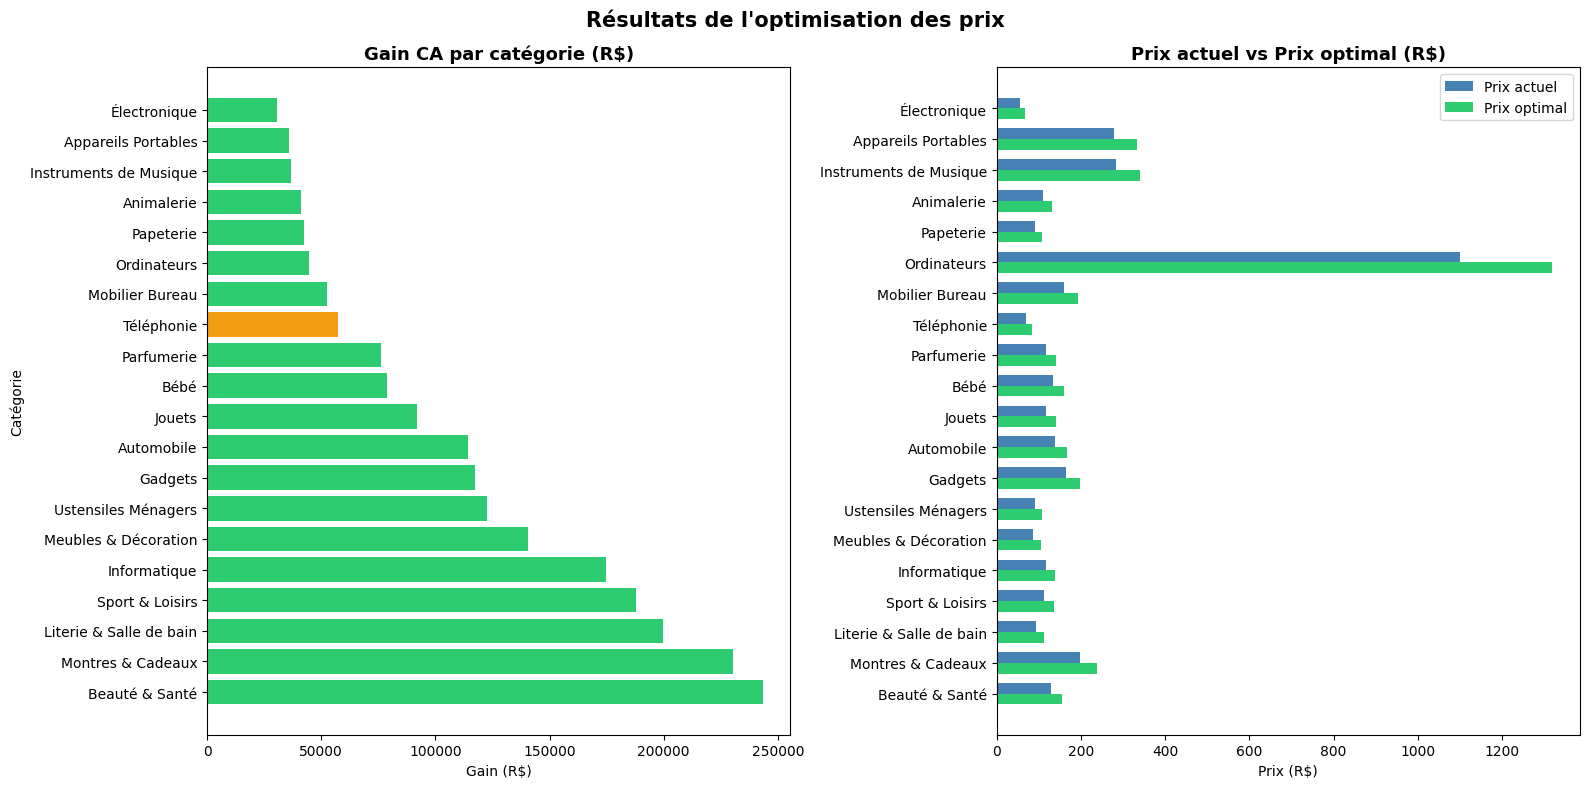

 Graphique sauvegardé dans outputs/


In [7]:
# ============================================================
# VISUALISATION DES GAINS PAR CATÉGORIE
# ============================================================

# Filtrer uniquement les catégories avec un gain > 0
optim_gain = optim_df[optim_df['gain_rs'] > 0].head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Graphique 1 : Gain en R$ par catégorie ---
couleurs = ['#2ecc71' if o == '🟢 Opportunité' 
            else '#f39c12' for o in optim_gain['opportunite']]

axes[0].barh(optim_gain['categorie'], optim_gain['gain_rs'], color=couleurs)
axes[0].set_title('Gain CA par catégorie (R$)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gain (R$)')
axes[0].set_ylabel('Catégorie')

# --- Graphique 2 : Prix actuel vs Prix optimal ---
x = range(len(optim_gain))
width = 0.35

axes[1].barh([i + width/2 for i in x], optim_gain['prix_actuel'], 
             width, label='Prix actuel', color='steelblue')
axes[1].barh([i - width/2 for i in x], optim_gain['prix_optimal'], 
             width, label='Prix optimal', color='#2ecc71')
axes[1].set_yticks(list(x))
axes[1].set_yticklabels(optim_gain['categorie'])
axes[1].set_title('Prix actuel vs Prix optimal (R$)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Prix (R$)')
axes[1].legend()

plt.suptitle('Résultats de l\'optimisation des prix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/optimisation_prix.png', dpi=150)
plt.show()

print(" Graphique sauvegardé dans outputs/")

## 6. Export des résultats et conclusion

In [8]:
# ============================================================
# EXPORT DES RÉSULTATS
# ============================================================

# Sauvegarder le tableau complet
optim_df.to_csv('../data/optimisation_prix.csv', index=False)
print(" Fichier exporté : data/optimisation_prix.csv")

# Résumé final
print(f"""
{'=' * 55}
         BILAN FINAL DE L'OPTIMISATION
{'=' * 55}

 CA total actuel   : {ca_total_actuel:>15,.0f} R$
 CA total optimal  : {ca_total_optimal:>15,.0f} R$
 Gain total        : {gain_total:>15,.0f} R$
 Gain en %         : {gain_total_pct:>14.1f}%

 Objectif initial  : +15%
 Objectif atteint  : +{gain_total_pct:.1f}%

 Catégories analysées  : {len(optim_df)}
 Opportunités          : {len(optim_df[optim_df['opportunite'] == '🟢 Opportunité'])}
 Prudence              : {len(optim_df[optim_df['opportunite'] == '🟡 Prudence'])}
 Risque (non touchées) : {len(optim_df[optim_df['opportunite'] == '🔴 Risque'])}
{'=' * 55}
""")

 Fichier exporté : data/optimisation_prix.csv

         BILAN FINAL DE L'OPTIMISATION

 CA total actuel   :      12,947,451 R$
 CA total optimal  :      15,371,613 R$
 Gain total        :       2,424,162 R$
 Gain en %         :           18.7%

 Objectif initial  : +15%
 Objectif atteint  : +18.7%

 Catégories analysées  : 53
 Opportunités          : 42
 Prudence              : 6
 Risque (non touchées) : 5



## 7. Conclusion

### Résultats obtenus
| Métrique | Valeur |
|---|---|
| CA actuel | 12 947 451 R$ |
| CA optimisé | 15 371 613 R$ |
| Gain total | 2 424 162 R$ |
| Gain en % | **+18.7%** ✅ |
| Objectif initial | +15% |

### Stratégie recommandée
| Segment | Nb catégories | Action |
|---|---|---|
| 🟢 Opportunité | 42 | Augmenter les prix jusqu'à +20% |
| 🟡 Prudence | 6 | Augmenter modérément (+5 à +10%) |
| 🔴 Risque | 5 | Maintenir les prix actuels |

### Top 3 catégories prioritaires
1. **Beauté & Santé** → +243 333 R$ (+19.7%)
2. **Montres & Cadeaux** → +230 154 R$ (+19.7%)
3. **Literie & Salle de bain** → +199 790 R$ (+19.5%).